In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


图已保存至: Refined_Results_v4\5.pdf


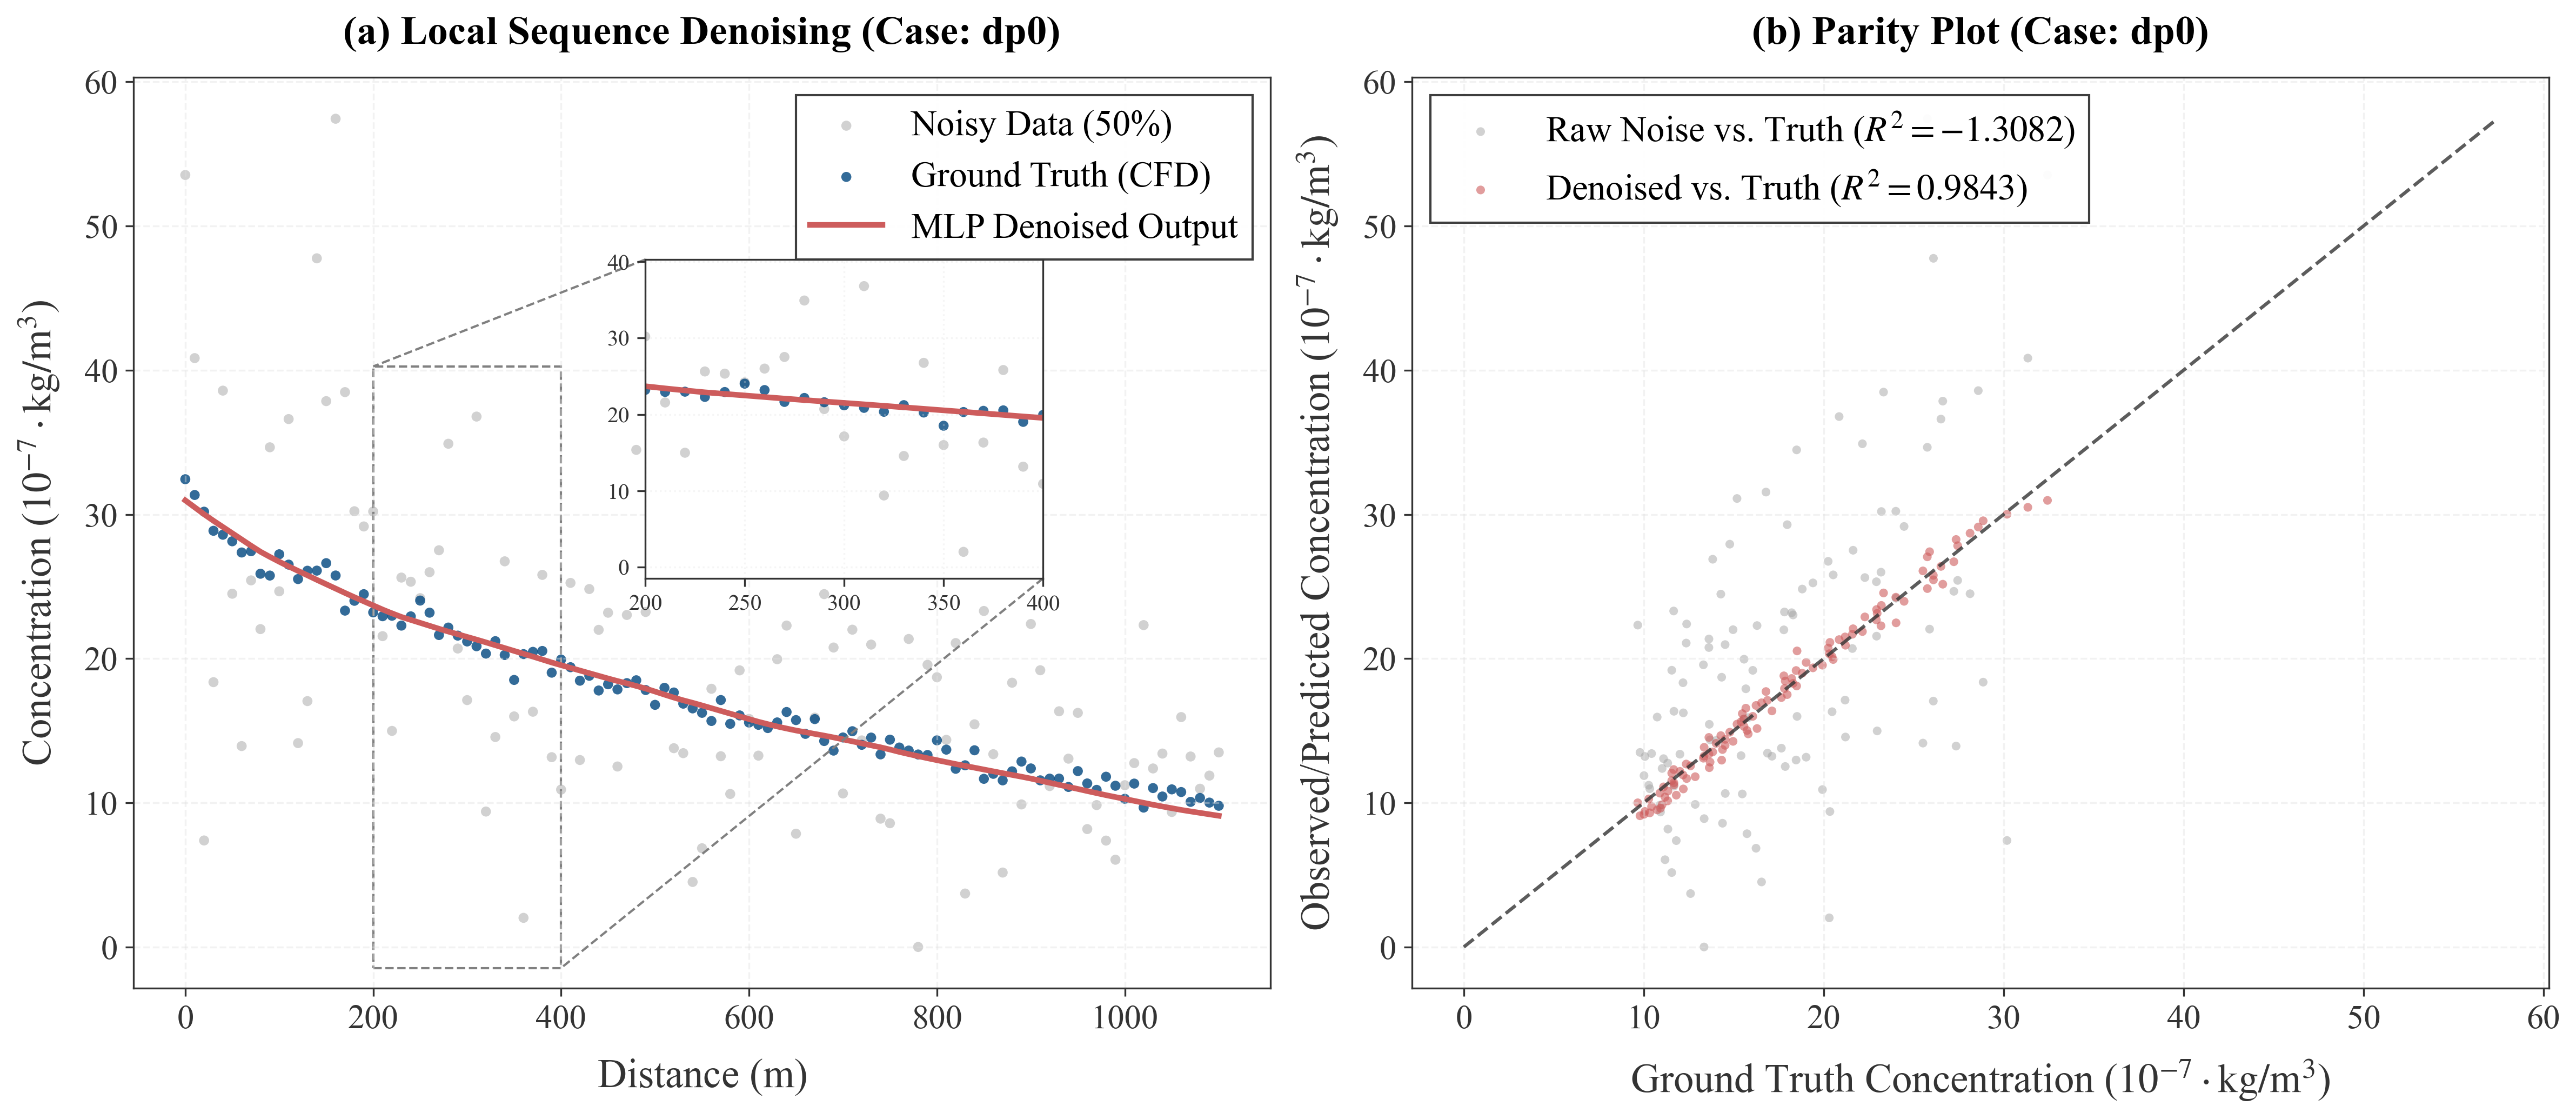

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import r2_score
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与风格设置
# ==========================================
# 应用统一的 VizConfig 配置，确保字体、DPI 等一致
VizConfig.set_style()

# 引用配置中的字号常量
TITLE_SIZE = VizConfig.TITLE_SIZE
LABEL_SIZE = VizConfig.LABEL_SIZE
TICK_SIZE = VizConfig.TICK_SIZE
LEGEND_SIZE = VizConfig.LEGEND_SIZE

OUTPUT_DIR = "Refined_Results_v4"
# 输入文件路径：包含 MLP 去噪前后的预测对比数据
INPUT_PATH = os.path.join(OUTPUT_DIR, "Noise_50pct", "predictions_comparison.csv")
# 预定义单位字符串，方便后续 label 使用
UNIT_C = r"($10^{-7} \cdot \text{kg/m}^3$)" 
UNIT_D = r"($\text{m}$)"

# ==========================================
# 1. 读取并准备数据
# ==========================================
# 检查数据是否存在，若不存在则生成模拟数据，保证绘图代码可运行
if not os.path.exists(INPUT_PATH) and not os.path.exists(os.path.dirname(INPUT_PATH)):
    print("Warning: 文件路径不存在，生成模拟数据用于演示代码逻辑...")
    # 模拟生成一条带有噪声和去噪结果的曲线
    dist = np.linspace(0, 1000, 200)
    # 真实值 (Clean Truth)
    clean = 10 * np.exp(-dist/300) + 2 * np.sin(dist/50)
    # 噪声值 (Noisy Input)
    noisy = clean + np.random.normal(0, 1, size=len(dist))
    # 预测值 (MLP Output - 模拟去噪效果)
    pred = clean + np.random.normal(0, 0.2, size=len(dist))
    
    case_df = pd.DataFrame({
        'Distance': dist, 'True_Clean': clean, 'True_Noisy': noisy, 'Pred_MLP': pred, 'Case': 'dp0'
    })
    r2_noisy, r2_denoised = 0.85, 0.98
    selected_case = "dp0"
else:
    if not os.path.exists(INPUT_PATH):
        print(f"错误：未找到数据文件 {INPUT_PATH}")
        exit()
    # 读取真实数据
    df = pd.read_csv(INPUT_PATH)
    selected_case = "dp0" # 选择一个特定的 Case 进行展示
    case_df = df[df['Case'] == selected_case].sort_values('Distance')
    # 计算 R2 分数
    r2_noisy = r2_score(case_df['True_Clean'], case_df['True_Noisy'])
    r2_denoised = r2_score(case_df['True_Clean'], case_df['Pred_MLP'])

# ==========================================
# 2. 开始绘图 (1x2 Subplots)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ------------------------------------------
# 子图 (a)：局部序列对比 (Local Sequence Denoising)
# ------------------------------------------
# 目的：直观展示去噪前后的序列形态对比

# 1. 绘制含噪数据点 (Noisy Data)
# 使用次要颜色 (灰色)，降低视觉权重，作为背景对比
ax1.scatter(case_df['Distance'], case_df['True_Noisy'], color=VizConfig.COLOR_SECONDARY, alpha=0.5, 
            s=20, label='Noisy Data (50%)', rasterized=True, edgecolors='none')

# 2. 绘制真实值数据点 (Ground Truth)
# 使用主色 (深蓝)，代表 Ground Truth
ax1.scatter(case_df['Distance'], case_df['True_Clean'], color=VizConfig.COLOR_MAIN, alpha=0.8,  s=20,
         label='Ground Truth (CFD)', rasterized=True, edgecolors='none')

# 3. 绘制去噪后的预测曲线 (MLP Output)
# 使用高亮色 (红色实线)，突出展示模型的输出效果
ax1.plot(case_df['Distance'], case_df['Pred_MLP'], color=VizConfig.COLOR_HIGHLIGHT, linestyle='-', 
         linewidth=2.5, label='MLP Denoised Output')

# 设置轴标签与标题
ax1.set_xlabel(f"Distance {UNIT_D}", fontsize=LABEL_SIZE, labelpad=10)
ax1.set_ylabel(f"Concentration {UNIT_C}", fontsize=LABEL_SIZE, labelpad=10)
ax1.set_title(f"(a) Local Sequence Denoising (Case: {selected_case})", fontsize=TITLE_SIZE, pad=15, fontweight='bold')
ax1.tick_params(labelsize=TICK_SIZE)
ax1.legend(fontsize=LEGEND_SIZE, loc='upper right', frameon=True)
ax1.grid(True, alpha=0.4, linestyle='--')

# ==========================================
# [关键特性] 添加嵌入式放大图 (Inset Plot)
# ==========================================
# 在主图 (ax1) 中创建一个子区域用于放大显示细节
# [0.45, 0.45, 0.35, 0.35] 分别代表 [x, y, width, height] 的相对比例坐标
axins = ax1.inset_axes([0.45, 0.45, 0.35, 0.35]) 

# 在放大区域中重新绘制同样的数据，保持颜色一致
axins.scatter(case_df['Distance'], case_df['True_Noisy'], color=VizConfig.COLOR_SECONDARY, alpha=0.5, s=20, rasterized=True, edgecolors='none')
axins.scatter(case_df['Distance'], case_df['True_Clean'], color=VizConfig.COLOR_MAIN, alpha=0.8, s=20, rasterized=True, edgecolors='none')
axins.plot(case_df['Distance'], case_df['Pred_MLP'], color=VizConfig.COLOR_HIGHLIGHT, linestyle='-', linewidth=2.5)

# 设置放大的 X 轴范围 (Zoom-in Region)
x1, x2 = 200, 400
axins.set_xlim(x1, x2)

# 自动计算放大区域对应的 Y 轴范围，避免手动写死
mask_zoom = (case_df['Distance'] >= x1) & (case_df['Distance'] <= x2)
y_data_segment = pd.concat([
    case_df.loc[mask_zoom, 'True_Noisy'],
    case_df.loc[mask_zoom, 'True_Clean'],
    case_df.loc[mask_zoom, 'Pred_MLP']
])

if not y_data_segment.empty:
    y_min, y_max = y_data_segment.min(), y_data_segment.max()
    y_margin = (y_max - y_min) * 0.1 
    axins.set_ylim(y_min - y_margin, y_max + y_margin)

# 调整子图样式
axins.tick_params(labelsize=10)
axins.grid(True, alpha=0.3, linestyle=':')
# 设置子图边框颜色
axins.spines['bottom'].set_color(VizConfig.COLOR_AXIS)
axins.spines['left'].set_color(VizConfig.COLOR_AXIS)

# 绘制连接线，连接主图选区和放大图 (mark_inset)
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5", linestyle='--')

# ------------------------------------------
# 子图 (b)：对角线图 (Parity Plot)
# ------------------------------------------
# 目的：对比 "原始噪声 vs 真实值" 和 "去噪后 vs 真实值" 的分布情况

# 1. 绘制原始含噪数据 (Noisy vs Truth)
# 颜色：灰色 (Secondary)，显示原始数据的离散程度
ax2.scatter(case_df['True_Clean'], case_df['True_Noisy'], color=VizConfig.COLOR_SECONDARY, alpha=0.5, 
            s=15, label=f'Raw Noise vs. Truth ($R^2 = {r2_noisy:.4f}$)', rasterized=True, edgecolors='none')

# 2. 绘制去噪后数据 (Denoised vs Truth)
# 颜色：红色 (Highlight)，显示去噪后的收敛程度
ax2.scatter(case_df['True_Clean'], case_df['Pred_MLP'], color=VizConfig.COLOR_HIGHLIGHT, alpha=0.6, 
            s=15, label=f'Denoised vs. Truth ($R^2 = {r2_denoised:.4f}$)', rasterized=True, edgecolors='none')

# 3. 绘制对角线 (Identity Line y=x)
all_vals = pd.concat([case_df['True_Clean'], case_df['True_Noisy'], case_df['Pred_MLP']])
lower_bound = all_vals.min()
upper_bound = all_vals.max()

ax2.plot([lower_bound, upper_bound], [lower_bound, upper_bound], 
         color=VizConfig.COLOR_AXIS, linestyle='--', alpha=0.8, linewidth=1.5, zorder=3)

# 设置轴标签与标题
ax2.set_xlabel(f"Ground Truth Concentration {UNIT_C}", fontsize=LABEL_SIZE, labelpad=10)
ax2.set_ylabel(f"Observed/Predicted Concentration {UNIT_C}", fontsize=LABEL_SIZE, labelpad=10)
ax2.set_title(f"(b) Parity Plot (Case: {selected_case})", fontsize=TITLE_SIZE, pad=15, fontweight='bold')
ax2.tick_params(labelsize=TICK_SIZE)
ax2.legend(fontsize=LEGEND_SIZE, loc='upper left')
ax2.grid(True, alpha=0.4, linestyle='--')

# ==========================================
# 3. 保存与输出
# ==========================================
plt.tight_layout()

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

output_pdf = os.path.join(OUTPUT_DIR, "5.pdf")
plt.savefig(output_pdf, dpi=VizConfig.DPI, bbox_inches='tight', pad_inches=0.1) 

print(f"图已保存至: {output_pdf}")
plt.show()